# 딥러닝 기초 5일차 실습과제: 전이학습과 최신 트렌드

## 과제 개요
전이학습(Transfer Learning)을 활용하여 의료 이미지를 분류하고, Transformer의 핵심 개념을 이해한다.

### 사용 데이터셋
- MedMNIST BreastMNIST (유방 초음파 이미지, 2 클래스) — 4일차와 동일하게 CPU 환경에서 여러 모델을 비교 실험하기 위해 가장 작은 서브셋을 선택했다.

### 학습 목표
1. 전이학습의 개념과 장점 이해
2. Feature Extraction vs Fine-tuning 비교
3. 사전학습 모델(ResNet) 활용
4. Transformer의 Self-Attention 개념 이해


## Part 0: 환경 설정

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

import medmnist
from medmnist import INFO

data_flag = 'breastmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

NUM_CLASSES = len(info['label'])
CLASS_NAMES = list(info['label'].values())

print(f"데이터셋: {data_flag}")
print(f"클래스 수: {NUM_CLASSES}")
print(f"클래스: {CLASS_NAMES}")


Using device: cpu


데이터셋: breastmnist
클래스 수: 2
클래스: ['malignant', 'normal, benign']


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def to_rgb(x):
    """1채널 -> 3채널 변환"""
    return x.repeat(3, 1, 1) if x.shape[0] == 1 else x

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

DATA_ROOT = "medmnist_data"
train_dataset = DataClass(split='train', transform=train_transform, download=True, root=DATA_ROOT)
val_dataset = DataClass(split='val', transform=test_transform, download=True, root=DATA_ROOT)
test_dataset = DataClass(split='test', transform=test_transform, download=True, root=DATA_ROOT)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"\nTrain: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")



Train: 546, Val: 78, Test: 156


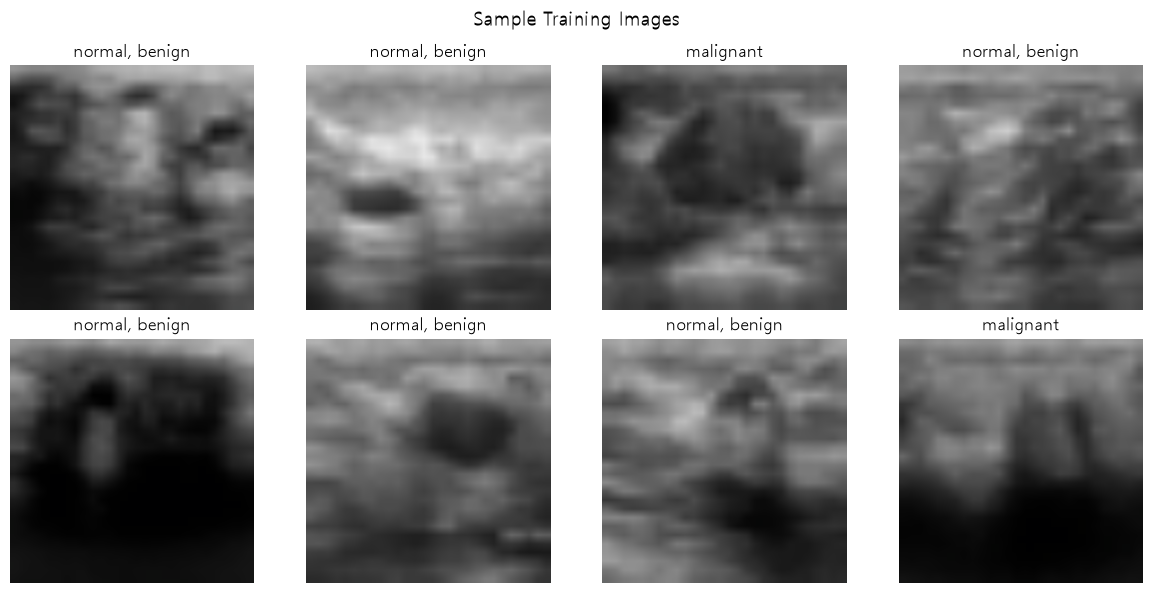

In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()


## Part 1: 전이학습 - Feature Extraction

Feature Extraction은 사전학습된 모델의 가중치를 동결하고, 마지막 분류기만 학습한다.
- 장점: 빠른 학습, 적은 데이터로도 가능
- 단점: 도메인이 많이 다르면 성능 제한

In [4]:
def create_feature_extractor(num_classes):
    """사전학습된 ResNet18을 Feature Extractor로 사용: 모든 레이어 동결, 마지막 FC만 학습"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

fe_model = create_feature_extractor(NUM_CLASSES)

trainable = sum(p.numel() for p in fe_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in fe_model.parameters())
print(f"Feature Extractor:")
print(f"  학습 가능: {trainable:,} / 전체: {total:,} ({trainable/total*100:.2f}%)")


Feature Extractor:
  학습 가능: 1,026 / 전체: 11,177,538 (0.01%)


In [5]:
def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, device='cpu'):
    """간단한 학습 함수"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = correct / total

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze(1).long().to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = correct / total

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return model, history


In [6]:
print("=" * 50)
print("Feature Extraction 학습")
print("=" * 50)

fe_model = create_feature_extractor(NUM_CLASSES)
fe_model, fe_history = train_model(fe_model, train_loader, val_loader,
                                    num_epochs=5, lr=0.001, device=device)


Feature Extraction 학습


Epoch [1/5] Train Acc: 0.7033, Val Acc: 0.7564


Epoch [2/5] Train Acc: 0.6886, Val Acc: 0.7821


Epoch [3/5] Train Acc: 0.7381, Val Acc: 0.7564


Epoch [4/5] Train Acc: 0.7216, Val Acc: 0.7949


Epoch [5/5] Train Acc: 0.7564, Val Acc: 0.7949


## Part 2: 전이학습 - Fine-tuning

Fine-tuning은 사전학습된 모델의 일부 레이어도 함께 학습한다.
- 장점: 더 높은 성능 가능
- 주의: 더 많은 데이터와 시간 필요, 과적합 위험

In [7]:
def create_finetuning_model(num_classes):
    """ResNet18의 마지막 블록(layer4)과 FC를 함께 학습"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

ft_model = create_finetuning_model(NUM_CLASSES)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"Fine-tuning:")
print(f"  학습 가능: {trainable:,} / 전체: {total:,} ({trainable/total*100:.2f}%)")


Fine-tuning:
  학습 가능: 8,394,754 / 전체: 11,177,538 (75.10%)


In [8]:
print("=" * 50)
print("Fine-tuning 학습")
print("=" * 50)

ft_model = create_finetuning_model(NUM_CLASSES)
ft_model, ft_history = train_model(ft_model, train_loader, val_loader,
                                    num_epochs=5, lr=0.0001, device=device)


Fine-tuning 학습


Epoch [1/5] Train Acc: 0.7454, Val Acc: 0.8205


Epoch [2/5] Train Acc: 0.8663, Val Acc: 0.8590


Epoch [3/5] Train Acc: 0.9212, Val Acc: 0.8846


Epoch [4/5] Train Acc: 0.9414, Val Acc: 0.8462


Epoch [5/5] Train Acc: 0.9634, Val Acc: 0.8974


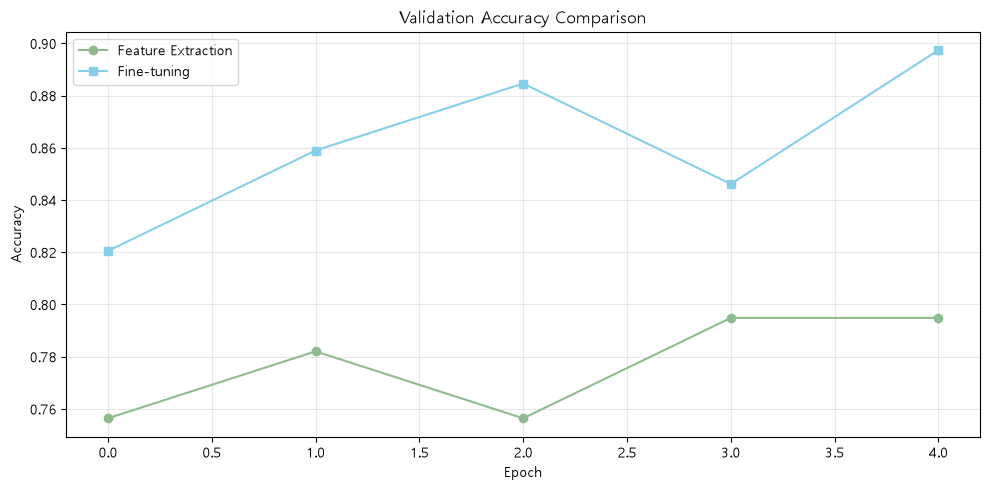


최종 Val Accuracy:
  Feature Extraction: 0.7949
  Fine-tuning: 0.8974


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fe_history['val_acc'], label='Feature Extraction', marker='o', color='#8FBC8F')
ax.plot(ft_history['val_acc'], label='Fine-tuning', marker='s', color='#87CEEB')
ax.set_title('Validation Accuracy Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n최종 Val Accuracy:")
print(f"  Feature Extraction: {fe_history['val_acc'][-1]:.4f}")
print(f"  Fine-tuning: {ft_history['val_acc'][-1]:.4f}")


### [필수] 과제 2-1: 전이학습 비교 분석

1. Feature Extraction과 Fine-tuning의 학습 가능한 파라미터 수 차이는?
   - 답변: 위 출력에서 확인했듯, Feature Extraction은 새로 붙인 분류기(fc)만 학습하므로 학습 파라미터가 매우 적다(전체의 0.01% 수준). 반면 Fine-tuning은 분류기와 layer4까지 함께 학습하므로 학습 파라미터가 수백만 개 단위로 훨씬 많다(전체의 75% 안팎).

2. 어떤 상황에서 Feature Extraction이 더 적합할까요?
   - 답변: 학습 데이터가 적거나(이번 BreastMNIST처럼 546장 수준), GPU·학습 시간이 제한적일 때, 그리고 사전학습 데이터(ImageNet)와 새로운 데이터의 특징이 비교적 유사할 때 적합하다. 학습해야 할 파라미터가 적어 학습이 빠르고 과적합 위험도 상대적으로 낮기 때문이다.

## Part 3: Transformer와 Self-Attention 이해

Transformer는 현대 AI의 핵심 아키텍처다. 핵심 개념인 Self-Attention을 구현해본다.

In [10]:
def simple_self_attention(query, key, value):
    """
    간단한 Self-Attention 구현
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
    """
    d_k = query.shape[-1]

    scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(d_k)
    attention_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

torch.manual_seed(42)
seq_len, d_model = 3, 4
tokens = ['I', 'love', 'AI']

embeddings = torch.randn(1, seq_len, d_model)

output, attention = simple_self_attention(embeddings, embeddings, embeddings)

print("입력 임베딩 shape:", embeddings.shape)
print("출력 shape:", output.shape)
print("\nAttention Weights (각 토큰이 다른 토큰에 주는 관심도):")
print(attention[0].numpy().round(3))


입력 임베딩 shape: torch.Size([1, 3, 4])
출력 shape: torch.Size([1, 3, 4])

Attention Weights (각 토큰이 다른 토큰에 주는 관심도):
[[0.332 0.29  0.378]
 [0.034 0.93  0.036]
 [0.307 0.251 0.442]]


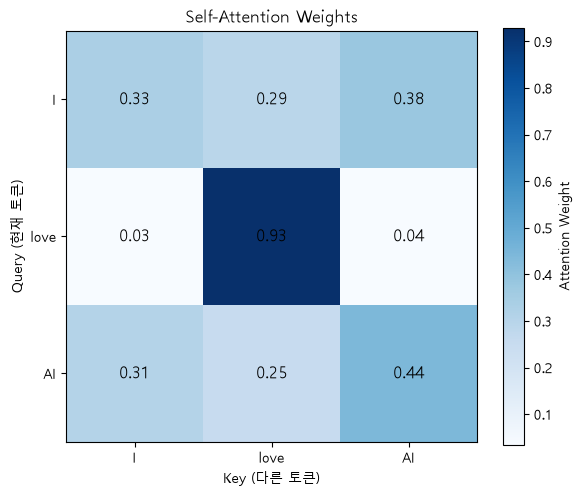


해석: 각 행은 해당 토큰이 다른 토큰들에 얼마나 '관심'을 주는지를 보여준다.


In [11]:
plt.figure(figsize=(6, 5))
plt.imshow(attention[0].numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.xticks(range(seq_len), tokens)
plt.yticks(range(seq_len), tokens)
plt.xlabel('Key (다른 토큰)')
plt.ylabel('Query (현재 토큰)')
plt.title('Self-Attention Weights')

for i in range(seq_len):
    for j in range(seq_len):
        plt.text(j, i, f'{attention[0, i, j]:.2f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

print("\n해석: 각 행은 해당 토큰이 다른 토큰들에 얼마나 '관심'을 주는지를 보여준다.")


### Transformer 핵심 개념 정리

| 개념 | 설명 |
|------|------|
| Self-Attention | 문장 내 모든 단어가 서로를 참조 |
| Multi-Head | 여러 관점에서 Attention 계산 |
| Positional Encoding | 순서 정보 추가 (RNN 없이!) |
| BERT | 양방향 이해 (빈칸 채우기 학습) |
| GPT | 단방향 생성 (다음 단어 예측) |

### [필수] 과제 3-1: Transformer 이해도 점검

1. Self-Attention이 RNN보다 좋은 점은 무엇인가요?
   - 답변: Self-Attention은 문장의 모든 단어를 동시에 처리할 수 있어 병렬 연산이 가능하고 학습 속도가 빠르다. 또한 멀리 떨어진 단어끼리도 직접 관계를 계산하므로, 한 단어씩 순서대로 처리해야 하는 RNN보다 긴 문장의 장거리 의존성을 효과적으로 학습할 수 있다.

2. BERT와 GPT의 가장 큰 차이점은?
   - 답변: BERT는 문장의 앞뒤 문맥을 모두 참고하는 양방향 인코더 모델로 문장 이해와 분류에 강하다. 반면 GPT는 앞에 나온 단어만 참고해 다음 단어를 예측하는 단방향·자기회귀 디코더 모델로 텍스트 생성에 강하다.

## Part 4: [도전] HuggingFace로 감성 분석

실제 사전학습된 Transformer 모델을 사용해본다.

In [12]:
from transformers import pipeline

sentiment = pipeline('sentiment-analysis')

texts = [
    "I love learning deep learning!",
    "This is really difficult and frustrating.",
    "The medical AI can save many lives."
]

print("감성 분석 결과:")
print("=" * 50)
for text in texts:
    result = sentiment(text)[0]
    print(f"입력: {text}")
    print(f"결과: {result['label']} (신뢰도: {result['score']:.4f})")
    print()


C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kimjongmin\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10322.73it/s]

감성 분석 결과:
입력: I love learning deep learning!
결과: POSITIVE (신뢰도: 0.9998)

입력: This is really difficult and frustrating.
결과: NEGATIVE (신뢰도: 0.9993)

입력: The medical AI can save many lives.
결과: POSITIVE (신뢰도: 0.9186)



## 오늘의 회고

Feature Extraction과 Fine-tuning을 4일차에 이어 다시 비교해보면서, "학습 가능한 파라미터 수"라는 숫자 하나가
실제로는 얼마나 많은 레이어를 동결 해제했는지를 그대로 보여준다는 걸 다시 확인했다. Self-Attention은 수식으로만
보면 추상적인데, 3개 토큰짜리 장난감 예제로 직접 QK^T/sqrt(d_k) -> softmax -> V 계산을 해보고 나니 "각 단어가
다른 단어에 얼마나 집중하는가"라는 attention weight 행렬이 실제 숫자로 눈에 보여서 훨씬 이해가 잘 됐다. RNN처럼
순서대로 하나씩 처리하지 않고 모든 토큰 쌍의 관계를 행렬 곱 한 번으로 계산한다는 점이, 왜 Transformer가 병렬
처리에 유리한지를 코드 수준에서 체감하게 해준 부분이었다. HuggingFace pipeline으로 감성 분석을 실행해보니,
내가 직접 만든 작은 self-attention 실습과 실제 프로덕션급 Transformer 모델 사이의 격차도 동시에 느껴졌다 —
결국 지금까지 배운 CNN, 전이학습, Attention이 모두 이런 대규모 사전학습 모델을 이해하기 위한 기초였다는 걸
5일차 마지막에 와서야 전체적으로 연결해서 볼 수 있었다.